# Investigation: Ordibehesht 1405 default-rate jump


## Setup

In [74]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

In [43]:
load_dotenv('../.env')

DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = os.getenv('DB_PORT')
DB_NAME     = os.getenv('DB_NAME')

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [44]:
users             = pd.read_sql("SELECT * FROM users", engine)
app_events        = pd.read_sql("SELECT * FROM app_events", engine)
loan_applications = pd.read_sql("SELECT * FROM loan_applications", engine)
installments      = pd.read_sql("SELECT * FROM installments", engine)
repayments        = pd.read_sql("SELECT * FROM repayments", engine)
dim_date          = pd.read_sql("SELECT * FROM dim_date", engine)

#### `status` casing

In [82]:
loan_applications['status'] = loan_applications['status'].str.upper()
loan_applications['created_at'] = pd.to_datetime(loan_applications['created_at'])

raw_status = pd.read_sql("SELECT status, created_at FROM loan_applications", engine)
raw_status['created_at'] = pd.to_datetime(raw_status['created_at'])
raw_status['month'] = raw_status['created_at'].dt.to_period('M')
print(pd.crosstab(raw_status['month'], raw_status['status']))

status   APPROVED  PENDING  REJECTED  approved  rejected
month                                                   
2025-09         0        0         0        16         9
2025-10         0        0         0       196       109
2025-11         0        0         0       259       168
2025-12         0        0         0       307       196
2026-01         0        0         0       361       236
2026-02       336        0       227         0         0
2026-03       473        0       324         0         0
2026-04      1026        0       604         0         0
2026-05      1170        0       728         0         0
2026-06       695      234       442         0         0


## Step 1 

No `is_default` column exists -- we have to construct default status from `installments` (due dates,
amounts) vs `repayments` (what was actually paid, when).

In [46]:
date_map = dim_date.set_index('date_jalali')['date_gregorian']
date_map.head()

date_jalali
1403/10/12    2025-01-01
1403/10/13    2025-01-02
1403/10/14    2025-01-03
1403/10/15    2025-01-04
1403/10/16    2025-01-05
Name: date_gregorian, dtype: object

In [47]:
installments['due_date_gregorian'] = pd.to_datetime(installments['due_date'].map(date_map))

unmapped = installments[installments['due_date_gregorian'].isna()]
print(f"{len(unmapped)} / {len(installments)} due dates failed to map")
print(unmapped['due_date'].value_counts().head())

1596 / 31494 due dates failed to map
due_date
1406/01/16    40
1406/01/22    36
1406/01/15    35
1406/01/09    34
1406/01/19    33
Name: count, dtype: int64


In [48]:
repayments['amount']

0        14660000
1        14660000
2         5840000
3        22450000
4        22450000
           ...   
12429     1860000
12430     1860000
12431     1860000
12432     1860000
12433     1860000
Name: amount, Length: 12434, dtype: int64

In [49]:
repayments.groupby('installment_id')['amount'].sum()

installment_id
4        14660000
5        14660000
16        5840000
28       22450000
30       22450000
           ...   
31490     1860000
31491     1860000
31492     1860000
31493     1860000
31494     1860000
Name: amount, Length: 12434, dtype: int64

In [50]:
repayments.columns

Index(['repayment_id', 'installment_id', 'paid_at', 'amount',
       'payment_method'],
      dtype='str')

In [51]:
inst = installments.merge(repayments[['installment_id', 'paid_at']], on='installment_id', how='left')
inst.head()

,installment_id,application_id,installment_no,due_date,amount,due_date_gregorian,paid_at
0,1,1,1,1405/02/30,25730000,2026-05-20,NaT
1,2,1,2,1405/03/29,25730000,2026-06-19,NaT
2,3,1,3,1405/04/28,25730000,2026-07-19,NaT
3,4,3,1,1405/03/19,14660000,2026-06-09,2026-06-04 21:19:06
4,5,3,2,1405/04/18,14660000,2026-07-09,2026-07-05 04:32:24


In [52]:
paid = inst[inst['paid_at'].notna()].copy()
paid.shape

(12434, 7)

In [53]:
paid[['paid_at', 'due_date_gregorian']].head()

,paid_at,due_date_gregorian
3,2026-06-04 21:19:06,2026-06-09
4,2026-07-05 04:32:24,2026-07-09
15,2026-06-23 19:52:31,2026-06-18
27,2026-04-03 17:59:55,2026-04-02
29,2026-07-12 05:38:33,2026-06-01


In [54]:
paid['lag_days'] = (pd.to_datetime(paid['paid_at']) - paid['due_date_gregorian']).dt.days
print(paid['lag_days'].describe())
print("paid within 7 days of due date:", (paid['lag_days'] <= 7).mean().round(3))
print("paid within 30 days of due date:", (paid['lag_days'] <= 30).mean().round(3))

count    12415.000000
mean       -18.567861
std         58.316321
min       -359.000000
25%         -5.000000
50%         -2.000000
75%          1.000000
max         55.000000
Name: lag_days, dtype: float64
paid within 7 days of due date: 0.969
paid within 30 days of due date: 0.982


In [55]:
SNAPSHOT = pd.Timestamp('2026-07-15')
GRACE_DAYS = 30  # 98% of payments land within 30 days of due date, so this is a safe cutoff

inst['had_grace_period'] = inst['due_date_gregorian'] < (SNAPSHOT - pd.Timedelta(days=GRACE_DAYS))
inst['defaulted'] = inst['had_grace_period'] & (inst['paid_at'].isna())

In [56]:


dim_date['date_gregorian'] = pd.to_datetime(dim_date['date_gregorian'])
jalali_lookup = dim_date.set_index('date_gregorian')[['jalali_year','jalali_month','jalali_month_name']]
inst = inst.merge(jalali_lookup, left_on='due_date_gregorian', right_index=True, how='left')

print(dim_date[(dim_date.jalali_year==1405)&(dim_date.jalali_month==2)]['date_gregorian'].agg(['min','max']))

min   2026-04-21
max   2026-05-21
Name: date_gregorian, dtype: datetime64[s]


In [57]:
mature = inst[inst['had_grace_period']].copy()
monthly = mature.groupby(['jalali_year','jalali_month','jalali_month_name']).agg(
    n_installments=('installment_id','count'),
    n_defaulted=('defaulted','sum')
).reset_index()
monthly['default_rate'] = (monthly['n_defaulted'] / monthly['n_installments']).round(4)
monthly

,jalali_year,jalali_month,jalali_month_name,n_installments,n_defaulted,default_rate
0,1404.0,8.0,آبان,134,3,0.0224
1,1404.0,9.0,آذر,383,13,0.0339
2,1404.0,10.0,دی,660,30,0.0455
3,1404.0,11.0,بهمن,937,50,0.0534
4,1404.0,12.0,اسفند,1191,65,0.0546
5,1405.0,1.0,فروردین,1549,92,0.0594
6,1405.0,2.0,اردیبهشت,2272,215,0.0946
7,1405.0,3.0,خرداد,2462,354,0.1438


In [58]:
from statsmodels.stats.proportion import proportions_ztest

farvardin   = monthly[(monthly.jalali_year==1405)&(monthly.jalali_month==1)].iloc[0]
ordibehesht = monthly[(monthly.jalali_year==1405)&(monthly.jalali_month==2)].iloc[0]

stat, pval = proportions_ztest(
    [farvardin.n_defaulted, ordibehesht.n_defaulted],
    [farvardin.n_installments, ordibehesht.n_installments]
)
print(f"Farvardin {farvardin.default_rate:.2%} -> Ordibehesht {ordibehesht.default_rate:.2%}")
print(f"z = {stat:.3f}, p = {pval:.2e}")

Farvardin 5.94% -> Ordibehesht 9.46%
z = -3.934, p = 8.35e-05


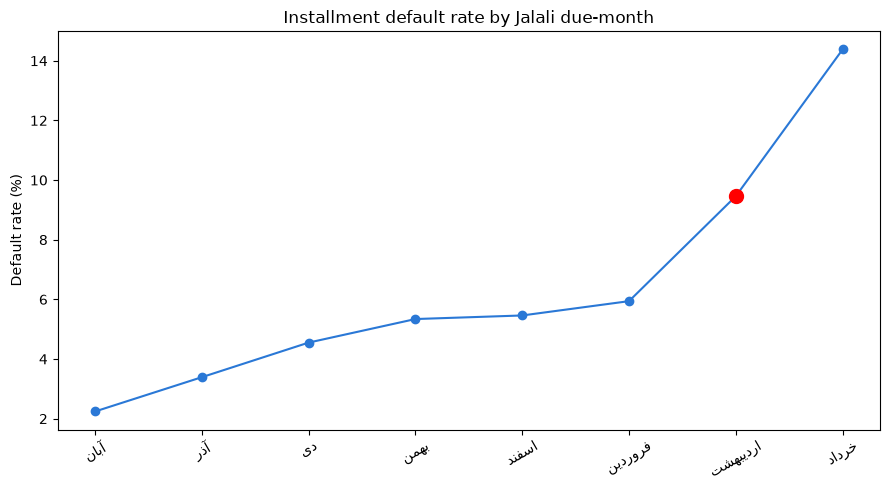

In [59]:
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(monthly['jalali_month_name'], monthly['default_rate']*100, marker='o', color='#2a78d6')
ord_idx = monthly.index[(monthly.jalali_year==1405)&(monthly.jalali_month==2)][0]
ax.scatter(monthly['jalali_month_name'][ord_idx], monthly['default_rate'][ord_idx]*100, color='red', zorder=5, s=100)
ax.set_ylabel('Default rate (%)')
ax.set_title('Installment default rate by Jalali due-month')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 2  Why

In [60]:
loan_cols = loan_applications[['application_id','user_id','created_at','approved_at',
                                'requested_amount','n_installments','status']]
loan_applications['approved_at'] = pd.to_datetime(loan_applications['approved_at'])
inst_full = inst.merge(loan_cols, on='application_id', how='left')
inst_full = inst_full.merge(users[['user_id','acquisition_channel','city']], on='user_id', how='left')


In [61]:
inst_full.head()

,installment_id,application_id,installment_no,due_date,amount,due_date_gregorian,paid_at,had_grace_period,defaulted,jalali_year,jalali_month,jalali_month_name,user_id,created_at,approved_at,requested_amount,n_installments,status,acquisition_channel,city
0,1,1,1,1405/02/30,25730000,2026-05-20,NaT,True,True,1405.0,2.0,اردیبهشت,2,2026-04-18 12:14:34,2026-04-20 06:37:37,7300000,3.0,APPROVED,organic,تهران
1,2,1,2,1405/03/29,25730000,2026-06-19,NaT,False,False,1405.0,3.0,خرداد,2,2026-04-18 12:14:34,2026-04-20 06:37:37,7300000,3.0,APPROVED,organic,تهران
2,3,1,3,1405/04/28,25730000,2026-07-19,NaT,False,False,1405.0,4.0,تیر,2,2026-04-18 12:14:34,2026-04-20 06:37:37,7300000,3.0,APPROVED,organic,تهران
3,4,3,1,1405/03/19,14660000,2026-06-09,2026-06-04 21:19:06,True,False,1405.0,3.0,خرداد,4,2026-05-09 06:57:35,2026-05-10 09:24:32,14300000,12.0,APPROVED,referral,تهران
4,5,3,2,1405/04/18,14660000,2026-07-09,2026-07-05 04:32:24,False,False,1405.0,4.0,تیر,4,2026-05-09 06:57:35,2026-05-10 09:24:32,14300000,12.0,APPROVED,referral,تهران


In [62]:
inst_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 31494 entries, 0 to 31493
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   installment_id       31494 non-null  int64         
 1   application_id       31494 non-null  int64         
 2   installment_no       31494 non-null  int64         
 3   due_date             31494 non-null  str           
 4   amount               31494 non-null  int64         
 5   due_date_gregorian   29898 non-null  datetime64[s] 
 6   paid_at              12434 non-null  datetime64[us]
 7   had_grace_period     31494 non-null  bool          
 8   defaulted            31494 non-null  bool          
 9   jalali_year          29898 non-null  float64       
 10  jalali_month         29898 non-null  float64       
 11  jalali_month_name    29898 non-null  str           
 12  user_id              31494 non-null  int64         
 13  created_at           31494 non-null  datet

In [64]:
inst_full['days_after_approval'] = (inst_full['due_date_gregorian'] - inst_full['approved_at']).dt.days
inst_full.groupby('installment_no')['days_after_approval'].median().head(6)

installment_no
1     29.0
2     59.0
3     89.0
4    119.0
5    149.0
6    179.0
Name: days_after_approval, dtype: float64

In [80]:
mature = inst_full[inst_full['had_grace_period']].copy()
ordibehesht = mature[(mature.jalali_year==1405)&(mature.jalali_month==2)]

print("default rate by installment_no, within Ordibehesht")
print(ordibehesht.groupby('installment_no')['defaulted'].agg(['mean','count']))

default rate by installment_no, within Ordibehesht
                    mean  count
installment_no                 
1               0.148664    861
2               0.053922    408
3               0.074866    374
4               0.066667    240
5               0.061798    178
6               0.056180    178
7               0.000000     33


In [81]:
print("default rate by acquisition_channel, within Ordibehesht")
print(ordibehesht.groupby('acquisition_channel')['defaulted'].agg(['mean','count']).sort_values('mean', ascending=False))

default rate by acquisition_channel, within Ordibehesht
                         mean  count
acquisition_channel                 
sms_campaign         0.261494    348
instagram            0.067437    519
google_ads           0.064789    355
organic              0.064010    828
referral             0.058559    222


In [78]:
print("default rate by channel, across all mature due-months")
print(mature.groupby(['jalali_month','acquisition_channel'])['defaulted']
      .mean().unstack('acquisition_channel').round(3))

default rate by channel, across all mature due-months
acquisition_channel  google_ads  instagram  organic  referral  sms_campaign
jalali_month                                                               
1.0                       0.076      0.070    0.050     0.046           NaN
2.0                       0.065      0.067    0.064     0.059         0.261
3.0                       0.059      0.074    0.085     0.060         0.319
8.0                       0.043      0.000    0.026     0.000           NaN
9.0                       0.046      0.023    0.031     0.054           NaN
10.0                      0.057      0.039    0.038     0.072           NaN
11.0                      0.053      0.044    0.055     0.069           NaN
12.0                      0.062      0.063    0.042     0.075           NaN


In [79]:
print("\nshare of installments from sms_campaign, by due-month")
print(mature.groupby('jalali_month')['acquisition_channel']
      .apply(lambda s: (s=='sms_campaign').mean()).round(3))


share of installments from sms_campaign, by due-month
jalali_month
1.0     0.000
2.0     0.153
3.0     0.285
8.0     0.000
9.0     0.000
10.0    0.000
11.0    0.000
12.0    0.000
Name: acquisition_channel, dtype: float64


In [77]:
ord_ex_sms = ordibehesht[ordibehesht['acquisition_channel'] != 'sms_campaign']
print("Ordibehesht actual:            ", ordibehesht['defaulted'].mean().round(4))
print("Ordibehesht excl. sms_campaign:", ord_ex_sms['defaulted'].mean().round(4))

Ordibehesht actual:             0.0946
Ordibehesht excl. sms_campaign: 0.0644


In [69]:
stat, pval = proportions_ztest(
    [farvardin.n_defaulted, ord_ex_sms['defaulted'].sum()],
    [farvardin.n_installments, len(ord_ex_sms)]
)
print(f"Farvardin vs Ordibehesht(ex-sms): z={stat:.3f}, p={pval:.4f}  <- no longer significant")

Farvardin vs Ordibehesht(ex-sms): z=-0.613, p=0.5397  <- no longer significant


In [70]:
total_jump_pp = (ordibehesht['defaulted'].mean() - farvardin.default_rate) * 100
residual_jump_pp = (ord_ex_sms['defaulted'].mean() - farvardin.default_rate) * 100
print(f"Total jump: {total_jump_pp:.2f}pp | Residual after removing sms_campaign: {residual_jump_pp:.2f}pp")
print(f"Share of jump explained by sms_campaign: {(1 - residual_jump_pp/total_jump_pp)*100:.0f}%")

Total jump: 3.52pp | Residual after removing sms_campaign: 0.50pp
Share of jump explained by sms_campaign: 86%


In [71]:
users['signup_at'] = pd.to_datetime(users['signup_at'])
users['signup_month'] = users['signup_at'].dt.to_period('M')
print(pd.crosstab(users['signup_month'], users['acquisition_channel']))
print("\nearliest sms_campaign signup:", users.loc[users.acquisition_channel=='sms_campaign','signup_at'].min())

acquisition_channel  google_ads  instagram  organic  referral  sms_campaign
signup_month                                                               
2025-09                      20         25       62        11             0
2025-10                      91        134      213        70             0
2025-11                     111        167      202        81             0
2025-12                     123        186      218        75             0
2026-01                     135        222      261       108             0
2026-02                     139        209      264        88             0
2026-03                     187        297      335       134           189
2026-04                     225        338      412       168           882
2026-05                     230        361      425       185           969
2026-06                     181        235      304       144           644

earliest sms_campaign signup: 2026-03-25 00:34:59


In [75]:
recent = loan_applications.merge(users[['user_id','acquisition_channel']], on='user_id', how='left')
recent = recent[recent['created_at'] >= '2026-03-25']
approval_rate = recent[recent.status!='PENDING'].groupby('acquisition_channel')['status']\
    .apply(lambda s: (s=='APPROVED').mean()).round(3)
print("approval rate by channel (applications since sms_campaign launch)")
print(approval_rate)

approval rate by channel (applications since sms_campaign launch)
acquisition_channel
google_ads      0.621
instagram       0.578
organic         0.621
referral        0.572
sms_campaign    0.636
Name: status, dtype: float64


In [76]:
print("median requested_amount by channel (approved loans, since launch)")
print(recent[recent.status=='APPROVED'].groupby('acquisition_channel')['requested_amount'].median())

median requested_amount by channel (approved loans, since launch)
acquisition_channel
google_ads      14700000.0
instagram       14700000.0
organic         14900000.0
referral        14600000.0
sms_campaign     8000000.0
Name: requested_amount, dtype: float64
